Generating Figure 1: Training Time...
  -> Saved: Plot 1.png
Generating Figure 2: Support Vector Count...
  -> Saved: Plot 2.png
Generating Figure 3: Residual vs Spatial Speedup...
  -> Saved: Plot 3.png

✅ All figures saved.


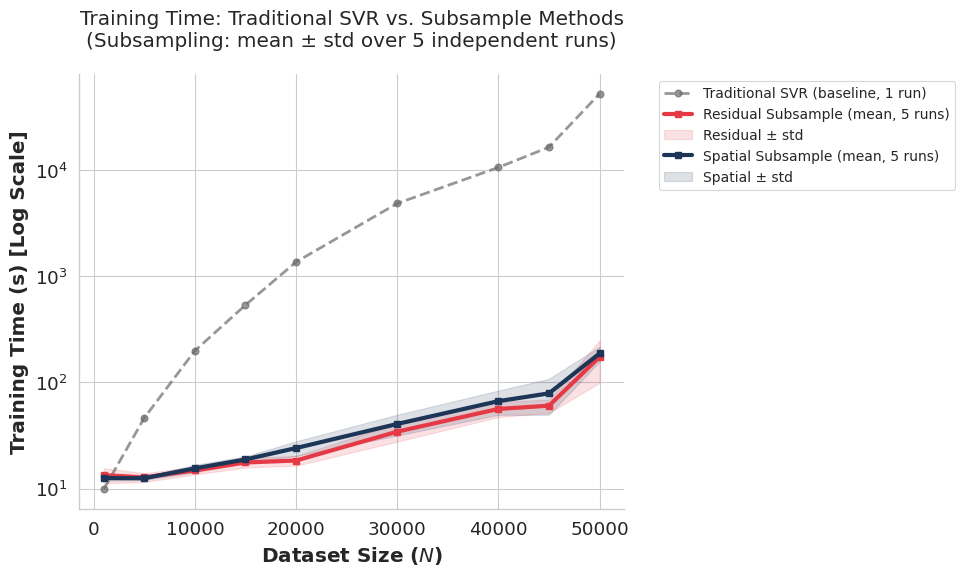

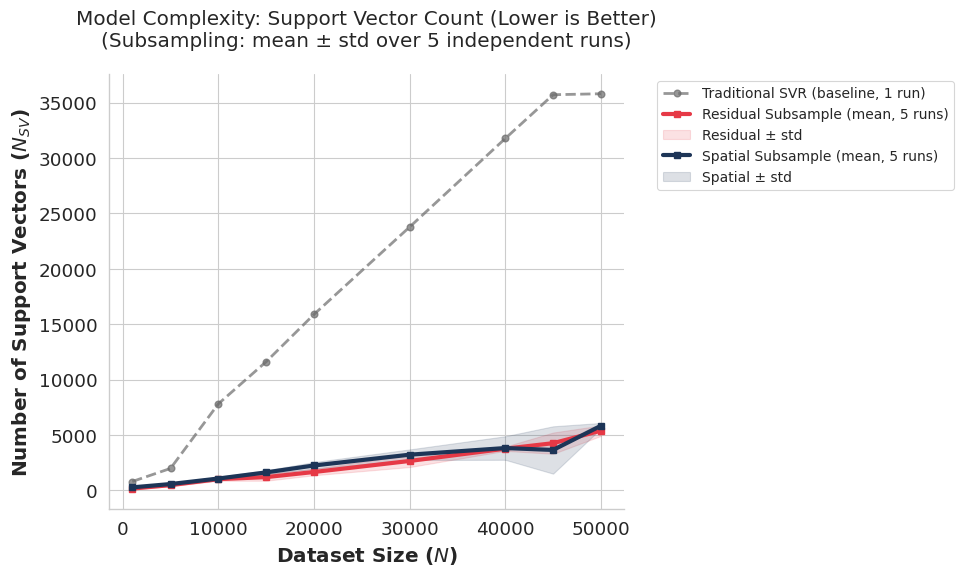

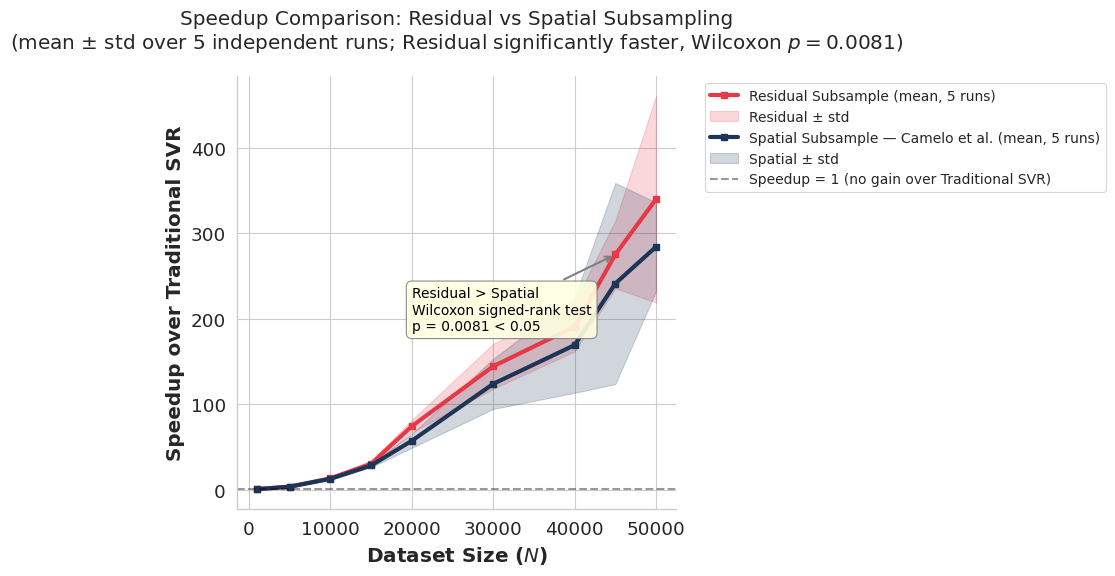

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# SVR VISUALIZER v3.0 - Multi-Run with Mean ± Std
# Only needs: summary_stats.csv
# ==========================================

class SVRResultsVisualizer:
    def __init__(self, summary_file='summary_stats.csv'):

        # Load multi-run summary
        self.summary = pd.read_csv(summary_file)
        self.res = self.summary[self.summary['criterion'] == 'Residual'].sort_values('n_samples')
        self.spa = self.summary[self.summary['criterion'] == 'Spatial'].sort_values('n_samples')

        # Traditional SVR — from Residual rows (same values in both criteria)
        # run once per n with random_state=42
        self.trad_n    = self.res['n_samples'].values
        self.trad_time = self.res['time_trad_mean'].values
        self.trad_n_sv = self.res['n_sv_trad_mean'].values

        # Style
        sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
        plt.rcParams['axes.spines.top']   = False
        plt.rcParams['axes.spines.right'] = False

        self.colors = {
            'Spatial':  "#1D3557",
            'Residual': "#E63946",
            'Trad':     "#6B6B6B",
        }

    def plot_scalability_evidence(self, save_as='Plot 1.png'):
        print("Generating Figure 1: Training Time...")
        fig, ax = plt.subplots(figsize=(10, 6))
        n = self.res['n_samples'].values

        # Traditional SVR
        ax.plot(self.trad_n, self.trad_time,
                color=self.colors['Trad'], linestyle='--',
                marker='o', linewidth=2, alpha=0.7,
                label='Traditional SVR (baseline, 1 run)')

        # Residual
        res_mean = self.res['time_sub_mean'].values
        res_std  = self.res['time_sub_std'].values
        ax.plot(n, res_mean, color=self.colors['Residual'],
                linestyle='-', marker='s', linewidth=3,
                label='Residual Subsample (mean, 5 runs)')
        ax.fill_between(n, np.maximum(0, res_mean - res_std),
                        res_mean + res_std,
                        color=self.colors['Residual'], alpha=0.15,
                        label='Residual ± std')

        # Spatial
        spa_mean = self.spa['time_sub_mean'].values
        spa_std  = self.spa['time_sub_std'].values
        ax.plot(n, spa_mean, color=self.colors['Spatial'],
                linestyle='-', marker='s', linewidth=3,
                label='Spatial Subsample (mean, 5 runs)')
        ax.fill_between(n, np.maximum(0, spa_mean - spa_std),
                        spa_mean + spa_std,
                        color=self.colors['Spatial'], alpha=0.15,
                        label='Spatial ± std')

        ax.set_yscale('log')
        ax.set_xlabel('Dataset Size ($N$)', fontweight='bold')
        ax.set_ylabel('Training Time (s) [Log Scale]', fontweight='bold')
        ax.set_title('Training Time: Traditional SVR vs. Subsample Methods\n'
                     '(Subsampling: mean ± std over 5 independent runs)', pad=20)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.tight_layout()
        plt.savefig(save_as, dpi=300, bbox_inches='tight')
        print(f"  -> Saved: {save_as}")

    def plot_sv_complexity_comparison(self, save_as='Plot 2.png'):
        print("Generating Figure 2: Support Vector Count...")
        fig, ax = plt.subplots(figsize=(10, 6))
        n = self.res['n_samples'].values

        # Traditional SVR
        ax.plot(self.trad_n, self.trad_n_sv,
                color=self.colors['Trad'], linestyle='--',
                marker='o', linewidth=2, alpha=0.7,
                label='Traditional SVR (baseline, 1 run)')

        # Residual
        res_mean = self.res['n_sv_sub_mean'].values
        res_std  = self.res['n_sv_sub_std'].values
        ax.plot(n, res_mean, color=self.colors['Residual'],
                linestyle='-', marker='s', linewidth=3,
                label='Residual Subsample (mean, 5 runs)')
        ax.fill_between(n, np.maximum(0, res_mean - res_std),
                        res_mean + res_std,
                        color=self.colors['Residual'], alpha=0.15,
                        label='Residual ± std')

        # Spatial
        spa_mean = self.spa['n_sv_sub_mean'].values
        spa_std  = self.spa['n_sv_sub_std'].values
        ax.plot(n, spa_mean, color=self.colors['Spatial'],
                linestyle='-', marker='s', linewidth=3,
                label='Spatial Subsample (mean, 5 runs)')
        ax.fill_between(n, np.maximum(0, spa_mean - spa_std),
                        spa_mean + spa_std,
                        color=self.colors['Spatial'], alpha=0.15,
                        label='Spatial ± std')

        ax.set_xlabel('Dataset Size ($N$)', fontweight='bold')
        ax.set_ylabel('Number of Support Vectors ($N_{SV}$)', fontweight='bold')
        ax.set_title('Model Complexity: Support Vector Count (Lower is Better)\n'
                     '(Subsampling: mean ± std over 5 independent runs)', pad=20)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.tight_layout()
        plt.savefig(save_as, dpi=300, bbox_inches='tight')
        print(f"  -> Saved: {save_as}")

    def plot_speedup(self, save_as='Plot 3_speedup.png'):
        print("Generating Figure 3: Speedup...")
        fig, ax = plt.subplots(figsize=(10, 6))
        n = self.res['n_samples'].values

        for label, data, color in [
            ('Residual', self.res, self.colors['Residual']),
            ('Spatial',  self.spa, self.colors['Spatial']),
        ]:
            mean = data['speedup_mean'].values
            std  = data['speedup_std'].values
            ax.plot(n, mean, color=color, linestyle='-',
                    marker='s', linewidth=3,
                    label=f'{label} Subsample (mean, 5 runs)')
            ax.fill_between(n, np.maximum(0, mean - std),
                            mean + std, color=color, alpha=0.15,
                            label=f'{label} ± std')

        ax.axhline(y=1, color='black', linestyle='--', alpha=0.5,
                   label='Speedup = 1 (no gain)')
        ax.set_xlabel('Dataset Size ($N$)', fontweight='bold')
        ax.set_ylabel('Speedup Factor', fontweight='bold')
        ax.set_title('Speedup over Traditional SVR\n'
                     '(mean ± std over 5 independent runs)', pad=20)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.tight_layout()
        plt.savefig(save_as, dpi=300, bbox_inches='tight')
        print(f"  -> Saved: {save_as}")





    def plot_speedup_comparison(self, save_as='Plot 3.png',
                                 wilcoxon_p=0.0081):
        """
        FIGURE 3 — Direct Residual vs Spatial speedup comparison
        Specifically addresses reviewer concern about statistical validation.
        Shows mean ± std across 5 runs + Wilcoxon p-value annotation.
        """
        print("Generating Figure 3: Residual vs Spatial Speedup...")
        fig, ax = plt.subplots(figsize=(10, 6))

        n = self.res['n_samples'].values

        # ── Residual ──
        res_mean = self.res['speedup_mean'].values
        res_std  = self.res['speedup_std'].values
        ax.plot(n, res_mean,
                color=self.colors['Residual'], linestyle='-',
                marker='s', linewidth=3,
                label='Residual Subsample (mean, 5 runs)')
        ax.fill_between(n,
                        np.maximum(0, res_mean - res_std),
                        res_mean + res_std,
                        color=self.colors['Residual'], alpha=0.2,
                        label='Residual ± std')

        # ── Spatial ──
        spa_mean = self.spa['speedup_mean'].values
        spa_std  = self.spa['speedup_std'].values
        ax.plot(n, spa_mean,
                color=self.colors['Spatial'], linestyle='-',
                marker='s', linewidth=3,
                label='Spatial Subsample — Camelo et al. (mean, 5 runs)')
        ax.fill_between(n,
                        np.maximum(0, spa_mean - spa_std),
                        spa_mean + spa_std,
                        color=self.colors['Spatial'], alpha=0.2,
                        label='Spatial ± std')

        # ── Speedup = 1 reference line ──
        ax.axhline(y=1, color='black', linestyle='--',
                   alpha=0.4, linewidth=1.5,
                   label='Speedup = 1 (no gain over Traditional SVR)')

        # ── Wilcoxon p-value annotation ──
        ax.annotate(
            f'Residual > Spatial\n'
            f'Wilcoxon signed-rank test\n'
            f'p = {wilcoxon_p:.4f} < 0.05',
            xy=(n[-2], res_mean[-2]),
            xytext=(n[4], res_mean[-1] * 0.55),
            fontsize=10,
            color='black',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow',
                      edgecolor='gray',
                      alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='gray',
                            lw=1.5)
        )

        ax.set_xlabel('Dataset Size ($N$)', fontweight='bold')
        ax.set_ylabel('Speedup over Traditional SVR', fontweight='bold')
        ax.set_title(
            'Speedup Comparison: Residual vs Spatial Subsampling\n'
            '(mean ± std over 5 independent runs; '
            'Residual significantly faster, Wilcoxon $p=0.0081$)',
            pad=20
        )
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.tight_layout()
        plt.savefig(save_as, dpi=300, bbox_inches='tight')
        print(f"  -> Saved: {save_as}")


# ==========================================
# EXECUTION — run this block only
# ==========================================
if __name__ == '__main__':
    viz = SVRResultsVisualizer(summary_file='summary_stats.csv')

    # Paper figures
    viz.plot_scalability_evidence(save_as='Plot 1.png')
    viz.plot_sv_complexity_comparison(save_as='Plot 2.png')

    # NEW — reviewer-focused figure with Wilcoxon annotation
    viz.plot_speedup_comparison(save_as='Plot 3.png', wilcoxon_p=0.0081)

    print("\n✅ All figures saved.")